In [25]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [11]:
eccodes_path = r'C:\ecCodes\eccodes-2.46.0-Source\bin'
os.environ['PATH'] = eccodes_path + os.pathsep + os.environ['PATH']

# if hasattr(os, 'add_dll_directory'):
#     try:
#         os.add_dll_directory(eccodes_path)
#     except Exception as e:
#         print(f"Warning: Could not add DLL directory: {e}")

import xarray as xr

In [13]:
base_path = Path(os.getcwd())

repo_root = base_path.parents[2]

In [19]:
ds = xr.open_dataset(f'{repo_root}/DataGRIB/lithuania_precip_2006.grib', engine='cfgrib')

print(ds)

<xarray.Dataset> Size: 1MB
Dimensions:     (time: 61, step: 4, latitude: 22, longitude: 49)
Coordinates:
  * time        (time) datetime64[ns] 488B 2006-11-01 2006-11-02 ... 2006-12-31
  * step        (step) timedelta64[ns] 32B 06:00:00 12:00:00 ... 1 days 00:00:00
  * latitude    (latitude) float64 176B 56.42 56.3 56.17 ... 54.05 53.92 53.8
  * longitude   (longitude) float64 392B 20.9 21.02 21.15 ... 26.65 26.77 26.9
    number      int64 8B ...
    surface     float64 8B ...
    valid_time  (time, step) datetime64[ns] 2kB ...
Data variables:
    tp          (time, step, latitude, longitude) float32 1MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-12T17:01 GRIB to CDM+CF via cfgrib-0.9.1..

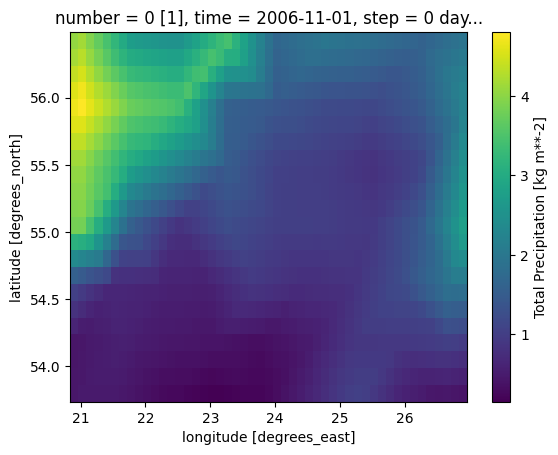

In [20]:
snapshot = ds.tp.isel(time=0, step=0)

snapshot.plot()

In [ ]:
df = ds.to_dataframe()

print(df.head())

Shape df: (263032, 4)
Shape df[0]: (4,)
                                               number  surface  \
time       step            latitude longitude                    
2006-11-01 0 days 06:00:00 56.425   20.900          0      0.0   
                                    21.025          0      0.0   
                                    21.150          0      0.0   
                                    21.275          0      0.0   
                                    21.400          0      0.0   

                                                       valid_time        tp  
time       step            latitude longitude                                
2006-11-01 0 days 06:00:00 56.425   20.900    2006-11-01 06:00:00  4.042237  
                                    21.025    2006-11-01 06:00:00  4.167068  
                                    21.150    2006-11-01 06:00:00  3.930662  
                                    21.275    2006-11-01 06:00:00  3.694403  
                             

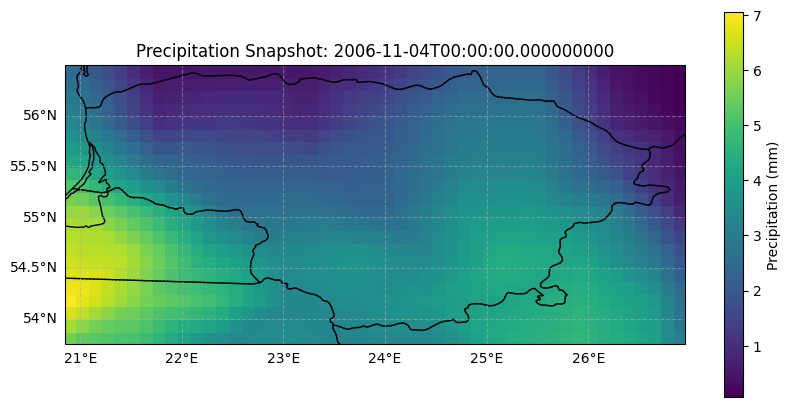

In [ ]:
snapshot = ds.tp.isel(time=3, step=1)

plt.figure(figsize=(10, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

plot = snapshot.plot(
    ax=ax, 
    transform=ccrs.PlateCarree(),
    add_colorbar=True,
    cbar_kwargs={'label': 'Precipitation (mm)'}
)

ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAND, edgecolor='black', facecolor='none')

gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
gl.top_labels = False
gl.right_labels = False

ax.add_feature(cfeature.BORDERS.with_scale('10m'))

ax.set_extent([20.85, 26.95, 53.75, 56.5], crs=ccrs.PlateCarree())

plt.title(f"Precipitation Snapshot: {snapshot.time.values}")
plt.show()